In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set non-TensorFlow seeds
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# 3. Import TensorFlow and set its seed last
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten,BatchNormalization

tf.random.set_seed(42)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

### DataSet

In [18]:
X, y = make_moons(100, noise=0.25,random_state=2) 

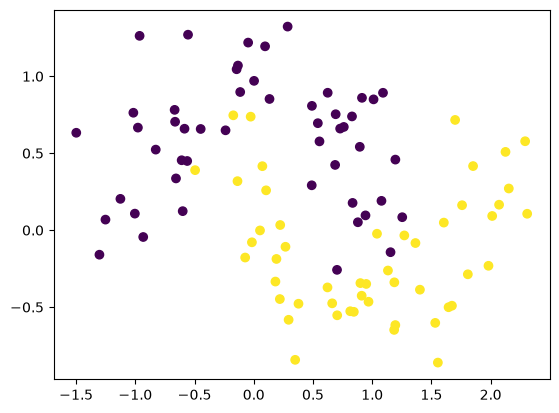

In [19]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

###  Without BatchNorm

In [20]:
model = Sequential([
    Dense(units=128, activation='relu', input_dim=2), 
    Dense(units=1, activation="sigmoid")
])

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model.fit(X, y, epochs=50, validation_split = 0.2,verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.6625 - loss: 0.6339 - val_accuracy: 0.8500 - val_loss: 0.5407
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7500 - loss: 0.5299 - val_accuracy: 0.9000 - val_loss: 0.4313
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8000 - loss: 0.4672 - val_accuracy: 0.9000 - val_loss: 0.3495
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8250 - loss: 0.4278 - val_accuracy: 0.9000 - val_loss: 0.2855
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8375 - loss: 0.4049 - val_accuracy: 0.9000 - val_loss: 0.2404
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8375 - loss: 0.3959 - val_accuracy: 0.9000 - val_loss: 0.2147
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8375 - loss: 0.3929 - val_accuracy: 0.9000 - val_loss: 0.2066
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8500 - loss: 0.3891 - val_accuracy: 0.9000 - val_loss: 0.2106

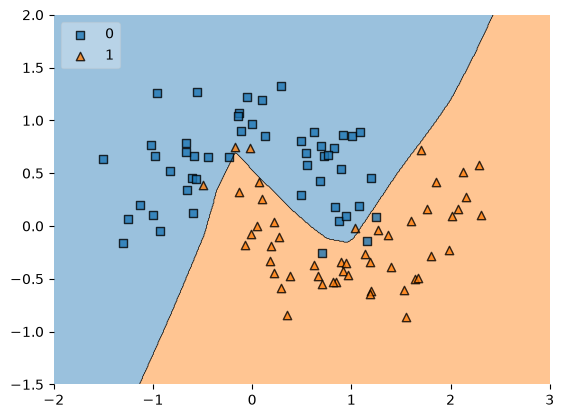

In [23]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()  # flatten to 1D int labels

wrapped_model = KerasClassifierWrapper(model)
plot_decision_regions(X, y.astype(int), clf=wrapped_model, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

### Using Batch Norm

In [24]:
model2 = Sequential([
    Dense(units=128, activation='relu', input_dim=2), 
    BatchNormalization(),
    Dense(units=1, activation="sigmoid")
])

In [25]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=50, validation_split = 0.2,verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.4750 - loss: 0.7881 - val_accuracy: 0.7000 - val_loss: 0.6226
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8000 - loss: 0.4686 - val_accuracy: 0.8000 - val_loss: 0.5953
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8250 - loss: 0.4595 - val_accuracy: 0.7000 - val_loss: 0.6028
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8375 - loss: 0.4168 - val_accuracy: 0.6000 - val_loss: 0.6231
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8500 - loss: 0.3703 - val_accuracy: 0.4500 - val_loss: 0.6438
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8750 - loss: 0.3296 - val_accuracy: 0.5000 - val_loss: 0.6576
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9000 - loss: 0.3011 - val_accuracy: 0.5000 - val_loss: 0.6610
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9125 - loss: 0.2831 - val_accuracy: 0.5500 - val_loss: 0.6522

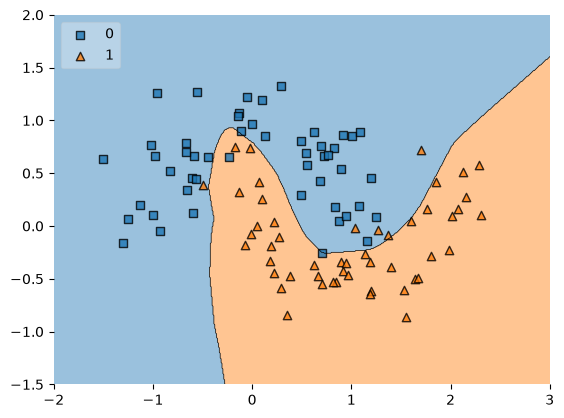

In [26]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()  # flatten to 1D int labels

wrapped_model = KerasClassifierWrapper(model2)
plot_decision_regions(X, y.astype(int), clf=wrapped_model, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

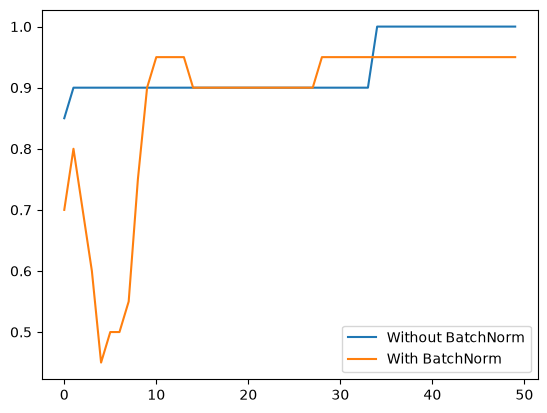

In [29]:
plt.plot(history1.history['val_accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.legend(['Without BatchNorm', 'With BatchNorm'])

plt.show()

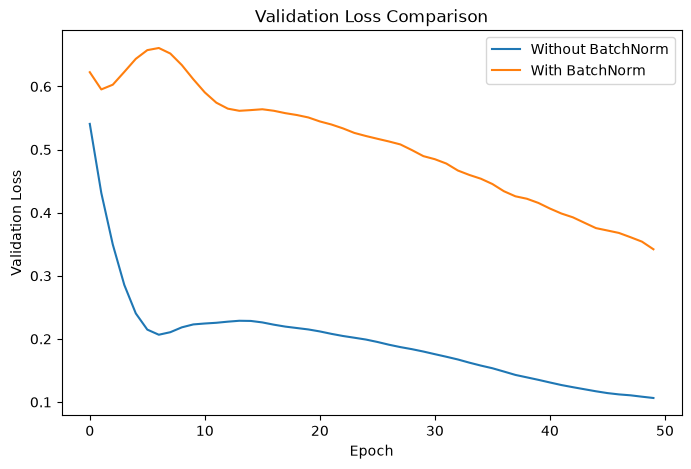

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history1.history['val_loss'], label='Without BatchNorm')
plt.plot(history2.history['val_loss'], label='With BatchNorm')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

### Conclusion : 
##### In this experiment, the model without Batch Normalization achieved higher validation accuracy (100%) and lower validation loss, indicating better performance on the validation set. The model with Batch Normalization trained more gradually but reached only about 95% validation accuracy with a higher validation loss. This suggests that for this small MLP and the simple make_moons dataset, Batch Normalization did not provide a performance advantage. Batch Normalization is generally more beneficial for deeper neural networks and larger, more complex datasets, where it helps stabilize training and improves convergence.